In [29]:
import numpy as np
import pandas as pd
from numpy import nan
from sklearn.preprocessing import  StandardScaler, OneHotEncoder, MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.datasets import make_classification 
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA, TruncatedSVD
from nltk.stem import SnowballStemmer
from sklearn import linear_model, datasets
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectKBest, SelectFpr, chi2, mutual_info_classif, f_classif
from sklearn.linear_model import SGDClassifier
from sklearn.metrics.pairwise import cosine_similarity
from nltk.stem import SnowballStemmer
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV

In [30]:
df = pd.read_csv('./winter_project_2026/development.csv')
df.dropna(inplace=True)


# unisco le colonne titolo e articolo in una colonna unica raddoppiando l'importanza del titolo
#text = df['title'] + ' ' + df['title'] + ' ' + df['article']
#df = pd.concat([df, text], axis=1)

#rinomino le colonne e droppo title e article
#df.rename(columns={0: 'text'}, inplace=True)
#df.drop(['title', 'article'], inplace=True, axis=1)
df.drop(['Id'], inplace=True, axis=1)
#df.drop_duplicates(inplace=True)
df.columns

Index(['source', 'title', 'article', 'page_rank', 'timestamp', 'label'], dtype='object')

In [31]:
weekdays = []
daytime = []
for day in df['timestamp']:
    if day == '0000-00-00 00:00:00':
        week_day = -1
        hour_day = -1
    else:
        week_day = pd.Timestamp(day).day_of_week
        hour = pd.Timestamp(day).hour
        if hour > 5 and hour <= 14:
            hour_day = 1        #morning
        elif hour > 14 and hour <= 21:
            hour_day = 2        #afternoon
        elif (hour > 21 and hour <= 23) or (hour >= 0 and hour <= 5):
            hour_day = 3        #night

    daytime.append(hour_day)
    weekdays.append(week_day)

df['day_of_week'] = weekdays
df['moment_of_day'] = daytime


In [33]:
import re
import string
from bs4 import BeautifulSoup

def clean_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r'<[^>]+>', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = re.sub(r'\W', ' ', text)  # Remove special characters
    text = BeautifulSoup(text, "html.parser").get_text()  # Remove HTML tags
    return text

from bs4 import BeautifulSoup, Comment
import re

def clean_html_professional(html_content):
    if not isinstance(html_content, str):
        return ""

    soup = BeautifulSoup(html_content, "html.parser") # lxml è più veloce di html.parser

    # 1. SALVARE I METADATA PREZIOSI (Opzionale, ma consigliato)
    meta_desc = ""
    meta_tag = soup.find('meta', attrs={'name': 'description'})
    if meta_tag and 'content' in meta_tag.attrs:
        meta_desc = meta_tag['content']

    # 2. GESTIONE JSON-LD (Dati strutturati)
    # Se vuoi estrarre info specifiche da qui, fallo ora prima di rimuovere gli script.

    # 3. RIMOZIONE DEL RUMORE (Decompose distrugge il tag e il suo contenuto)
    for tag in soup(['script', 'style', 'noscript', 'iframe', 'svg', 'header', 'footer', 'nav']):
        # Eccezione: se vuoi tenere JSON-LD, controlla l'attributo type prima di decomporre script
        tag.decompose()

    # Rimuovi commenti HTML
    comments = soup.find_all(string=lambda text: isinstance(text, Comment))
    for c in comments:
        c.extract()

    # 4. ESTRAZIONE ATTRIBUTI NASCOSTI (Come chiedevi per le immagini)
    # Sostituiamo l'immagine con il suo testo alternativo per non perderlo
    for img in soup.find_all('img'):
        if 'alt' in img.attrs and img['alt']:
            # Sostituisce <img> con il testo dell'alt
            img.replace_with(f" {img['alt']} ") 
    
    # 5. ESTRAZIONE TESTO (Gestione spaziature)
    # 'separator=" "' è CRUCIALE. Altrimenti <p>Hello</p><p>World</p> diventa "HelloWorld"
    text = soup.get_text(separator=' ', strip=True)
    
    # Aggiungiamo la meta description recuperata all'inizio
    final_text = f"{text} {meta_desc}"

    # 6. PULIZIA FINALE ENTITIES E SPAZI
    # BeautifulSoup gestisce le entità (&amp;) automaticamente in get_text(), 
    # ma rimuoviamo spazi multipli
    final_text = re.sub(r'\s+', ' ', final_text).strip()

    return final_text

for i, article in zip(df.index, df['article']):
    df.loc[i, 'article'] = clean_html_professional(article)

In [34]:
df['day_of_week'] = weekdays
df['moment_of_day'] = daytime

df['article_word_count'] = df['article'].apply(lambda x: len(str(x).split()))
df['title_word_count'] = df['title'].apply(lambda x: len(str(x).split()))

df.drop('timestamp', axis=1, inplace=True)

========== NUMBER OF ARTICLES CONTAINING LESS THAN 1 WORDS ===========
label
0    33
1     8
2    13
3     1
4     2
5    72
6     1
Name: article, dtype: int64


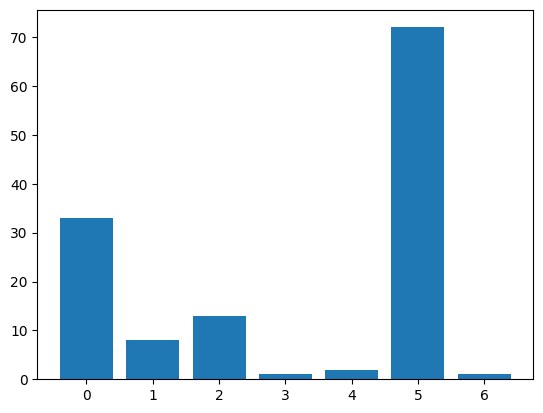

========== NUMBER OF ARTICLES CONTAINING LESS THAN 2 WORDS ===========
label
0      56
1     908
2      69
3      17
4       4
5    1024
6       1
Name: article, dtype: int64


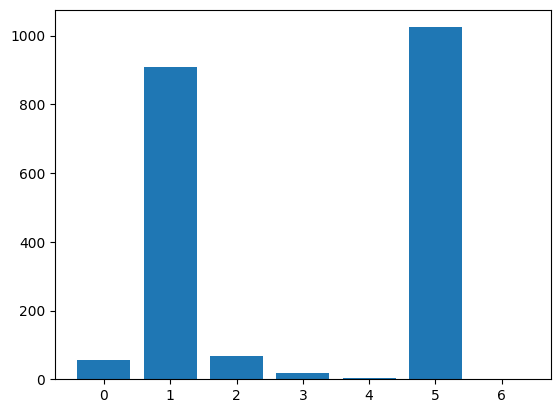

========== NUMBER OF ARTICLES CONTAINING LESS THAN 3 WORDS ===========
label
0      57
1     910
2      83
3      19
4       5
5    1197
6       1
Name: article, dtype: int64


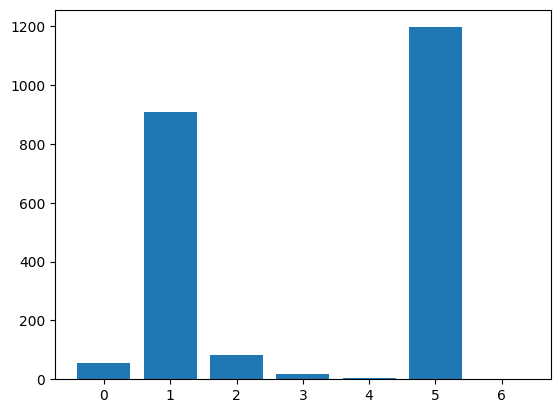

========== NUMBER OF ARTICLES CONTAINING LESS THAN 4 WORDS ===========
label
0      70
1     923
2     114
3      28
4       7
5    1242
6       1
Name: article, dtype: int64


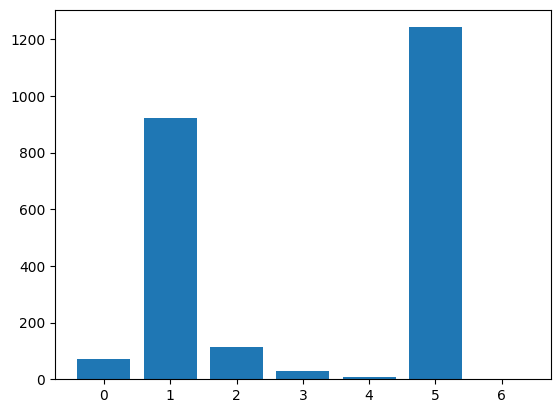

========== NUMBER OF ARTICLES CONTAINING LESS THAN 5 WORDS ===========
label
0      80
1     947
2     167
3      36
4      10
5    1355
6       1
Name: article, dtype: int64


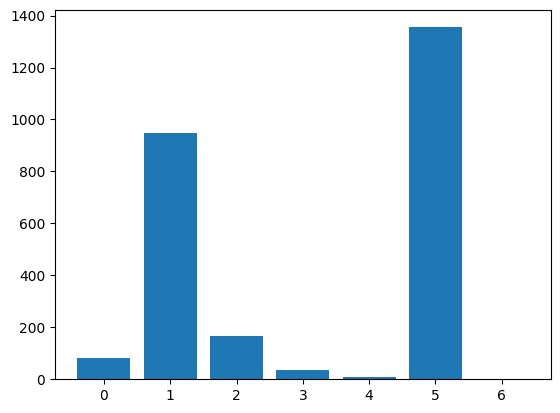

In [ ]:
for i in range(1,6):
    short_texts = df[df['article_word_count']  < i]
    grouped = short_texts.groupby('label')
    print(f'========== NUMBER OF ARTICLES CONTAINING LESS THAN {i} WORDS ===========')
    print(grouped['article'].count())
    plot = plt.bar( grouped['article'].count().index, grouped['article'].count().values)
    plt.show()

In [36]:
min_words = 3
max_words = 100

short_texts = (df['article_word_count'] < min_words)
print( f' articles with less than {min_words} words: {df[short_texts]['article'].count()}')

print(df[short_texts].groupby('label')['article'].count())

long_texts = (df['article_word_count'] > max_words)
print(f' articles with more than {max_words} words: {df[long_texts]['article'].count()}')

print(df[long_texts].groupby('label')['article'].count())

 articles with less than 3 words: 2273
label
0      57
1     911
2      83
3      18
4       5
5    1198
6       1
Name: article, dtype: int64
 articles with more than 100 words: 1637
label
0    676
1     71
2    492
3    247
4    109
6     42
Name: article, dtype: int64


In [37]:
print(df.groupby('label')['article_word_count'].mean())
print(df.groupby('label')['article_word_count'].std())
print(df.groupby('label')['article_word_count'].max())

label
0    37.269178
1    27.756872
2    44.759677
3    34.736293
4    35.717518
5    24.909216
6    32.456802
Name: article_word_count, dtype: float64
label
0    23.460432
1    16.673310
2    88.630085
3    21.096751
4    18.147406
5    11.999941
6    16.283938
Name: article_word_count, dtype: float64
label
0     403
1     184
2    1905
3     290
4     243
5      77
6     190
Name: article_word_count, dtype: int64


In [38]:
#df.drop(df[short_texts].index, inplace=True)
#df.drop(df[long_texts].index, inplace=True)


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 79995 entries, 0 to 79996
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   source              79995 non-null  object
 1   title               79995 non-null  object
 2   article             79995 non-null  object
 3   page_rank           79995 non-null  int64 
 4   label               79995 non-null  int64 
 5   day_of_week         79995 non-null  int64 
 6   moment_of_day       79995 non-null  int64 
 7   article_word_count  79995 non-null  int64 
 8   title_word_count    79995 non-null  int64 
dtypes: int64(6), object(3)
memory usage: 8.1+ MB


In [40]:
df['text'] = df['source'] + ' ' + df['title'] + ' ' + df['title'] + ' ' + df['article']

In [41]:
stemmer = SnowballStemmer('english')


def stemming_tokenizer(text):
    # Separa le parole
    words = text.split()
    # Applica lo stemmer a ogni parola e riunisci
    # (È qui che avviene la magia: "running" -> "run")
    stemmed_words = [stemmer.stem(word) for word in words]
    return " ".join(stemmed_words)

df['text'] = df['text'].apply(stemming_tokenizer)

In [ ]:
y = df['label']
df.drop('label', inplace=True, axis=1)
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)


In [ ]:
X_train

In [ ]:
stop_words = list(ENGLISH_STOP_WORDS) + [
    # --- Rumore HTML e Scraping ---
    'http', 'https', 'src', 'href', 'img', 'alignleft', 'alignright', 
    'height', 'width', 'border', 'clearall', 'borderimga', 'br', 'class',
    
    # --- Agenzie Stampa e Formattazione News ---
    'reuters', 'ap', 'afp', 'pa', 'upi', 'press', 'association',
    'new', 'york', 'london', 'washington', # Città ricorrenti nelle dateline
    'said', 'says', 'told', 'reported', 'added', # Verbi di reportistica
    
    # --- Temporali Generici (inutili per classificare l'argomento) ---
    'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday',
    'yesterday', 'today', 'tomorrow', 'year', 'years', 'week', 'month', 'day',
    'time', 'daily', 'date', 'attack', 'baghdad', 'bomb', 'bush', 'gaza', 'iran', 'iraq',
    'iraqi', 'israel', 'kerry', 'palestinian','british' ,'countri', 'court','death', 'democrat' ,'elect' ,'forc',
 'govern' ,'group' ,'kill', 'leader', 'militari', 'minist', 'nation', 'offici',
 'peopl', 'plan', 'polic', 'presid', 'prime', 'prime minist', 'reuters', 'secur',
 'state', 'talk' ,'unit', 'vote', 'war' ,'world']

stemmed_stop_words = [stemmer.stem(word) for word in stop_words]

TOP_K_PER_CLASS = 30

final_vocabulary = set() 
print("Estrazione vocabolario specifico per classe...")
classes = np.unique(y_train)

for label in classes:
    subset_text = X_train[y_train == label]['text']
    
    temp_vectorizer = TfidfVectorizer(
        max_features=TOP_K_PER_CLASS,
        stop_words=stemmed_stop_words,
        ngram_range=(1, 2),
        min_df=2,
    )
    temp_vectorizer.fit(subset_text)    
    
    words = temp_vectorizer.get_feature_names_out()
    print(label)
    print(words)
    final_vocabulary.update(words)
    print(f"Classe {label}: trovate {len(words)} parole specifiche.")

final_vocabulary_list = list(final_vocabulary)
print(f"Vocabolario totale ottimizzato: {len(final_vocabulary_list)} parole uniche.")



In [ ]:
stop_words = list(ENGLISH_STOP_WORDS) + [
    # --- Rumore HTML e Scraping ---
    'http', 'https', 'src', 'href', 'img', 'alignleft', 'alignright', 
    'height', 'width', 'border', 'clearall', 'borderimga', 'br', 'class']


encoder = OneHotEncoder(min_frequency=20, handle_unknown='infrequent_if_exist')

scaler = MinMaxScaler()

text_pipeline_selector = Pipeline([
    ('vect', TfidfVectorizer(
        stop_words=stemmed_stop_words,
        max_df = 0.8,
        max_features = 20000,
        use_idf=False
    )),
    ('selector', SelectFpr(score_func=chi2, alpha=0.001)),
    ('selector2', SelectFpr(score_func=f_classif, alpha=0.001))
])

vectorizer = TfidfVectorizer(
        max_features=30000,
        stop_words='english',
        min_df=3)

vectorizer_title = TfidfVectorizer(
        max_features=3000,
        stop_words=stemmed_stop_words,
        ngram_range=(1, 2),
        min_df=3)

preprocessor = ColumnTransformer(transformers=[
    ('text', text_pipeline_selector, 'text'),
   ('numerical', scaler, [ 'day_of_week', 'moment_of_day', 'article_word_count', 'title_word_count']),
    ('source', encoder, ['source'])
], remainder='drop')

preprocessor_article_only = ColumnTransformer(transformers=[
    ('day_of_week', scaler, ['day_of_week', 'moment_of_day', 'article_word_count', 'title_word_count'])], remainder='drop')


In [ ]:
X_train_final = preprocessor.fit_transform(X_train, y_train)
X_test_final = preprocessor.transform(X_test)


In [ ]:
X_train_final.shape

In [ ]:
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import confusion_matrix

weights = compute_sample_weight(class_weight='balanced', y=y_train)


clf = LogisticRegression(
    C=1,                       
    class_weight='balanced',    
    solver='liblinear',        
    penalty='l2',           
    max_iter=1000,              
    random_state=42
)
clf2 = RandomForestClassifier(
    random_state= 42,
    n_estimators=1500,
    max_depth=10,
    class_weight='balanced',
    n_jobs = -1
)

clf3 = GradientBoostingClassifier(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,
    random_state=42,
    warm_start=True,
)

svm = LinearSVC(C=1,
        class_weight='balanced',
        max_iter=2000,
        random_state=42
)


clf5 = XGBClassifier(
        n_estimators=1000,      
        learning_rate=0.05,     
        max_depth=6,             
        min_child_weight=1,
        gamma=0.1,           
        subsample=0.8,           
        colsample_bytree=0.8,     
        n_jobs=-1,               
        random_state=42,
        eval_metric='mlogloss'  
    )

clf_svm_prob = CalibratedClassifierCV(svm, method='sigmoid')
clf_nb = MultinomialNB()

voting_clf = VotingClassifier(
    estimators=[ 
        ('svm', clf_svm_prob), 
        ('xgb', clf5)
    ],
    voting='soft', weights=[2,1], verbose=True  # <--- Maggioranza secca
)


voting_clf.fit(X_train_final, y_train)

y_pred = voting_clf.predict(X_test_final)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix_fatta_bene(y_true, y_pred, labels):
    """
    y_true: lista delle etichette reali
    y_pred: lista delle etichette predette dal modello
    labels: lista dei nomi delle classi (es. ['Sport', 'Politica', 'Esteri'])
    """

    # 1. Calcolo della matrice NORMALIZZATA
    # normalize='true' fa sì che la somma di ogni RIGA sia 1 (100%).
    # Questo ti dice: "Della classe X, quanti ne ho indovinati?"
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize='true')

    # 2. Setup del grafico
    plt.figure(figsize=(10, 8)) # Dimensioni generose

    # 3. Disegno con Seaborn
    # annot=True: scrive i numeri nelle celle
    # fmt='.1%': formatta come percentuale con 1 decimale (es. 85.4%)
    # cmap='Blues': scala di blu (più scuro = più alto), ottima per report
    sns.heatmap(cm, 
                annot=True, 
                fmt='.1%', 
                xticklabels=labels, 
                yticklabels=labels, 
                cmap='Blues',
                cbar_kws={'label': 'Proporzione di predizioni'})

    # 4. Etichette assi (Cruciale per non confondersi)
    plt.ylabel('Realtà (True Label)', fontsize=12, fontweight='bold')
    plt.xlabel('Predizione (Predicted Label)', fontsize=12, fontweight='bold')
    plt.title('Confusion Matrix Normalizzata', fontsize=14)
    
    plt.tight_layout()
    plt.show()

# Esempio di utilizzo fittizio
# labels_list = ['Sport', 'Politica', 'Cronaca']
# plot_confusion_matrix_fatta_bene(y_test, predictions, labels_list)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix_fatta_bene(y_true, y_pred, labels):
    """
    y_true: lista delle etichette reali
    y_pred: lista delle etichette predette dal modello
    labels: lista dei nomi delle classi (es. ['Sport', 'Politica', 'Esteri'])
    """

    # 1. Calcolo della matrice NORMALIZZATA
    # normalize='true' fa sì che la somma di ogni RIGA sia 1 (100%).
    # Questo ti dice: "Della classe X, quanti ne ho indovinati?"
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize='true')

    # 2. Setup del grafico
    plt.figure(figsize=(10, 8)) # Dimensioni generose

    # 3. Disegno con Seaborn
    # annot=True: scrive i numeri nelle celle
    # fmt='.1%': formatta come percentuale con 1 decimale (es. 85.4%)
    # cmap='Blues': scala di blu (più scuro = più alto), ottima per report
    sns.heatmap(cm, 
                annot=True, 
                fmt='.1%', 
                xticklabels=labels, 
                yticklabels=labels, 
                cmap='Blues',
                cbar_kws={'label': 'Proporzione di predizioni'})

    # 4. Etichette assi (Cruciale per non confondersi)
    plt.ylabel('Realtà (True Label)', fontsize=12, fontweight='bold')
    plt.xlabel('Predizione (Predicted Label)', fontsize=12, fontweight='bold')
    plt.title('Confusion Matrix Normalizzata', fontsize=14)
    
    plt.tight_layout()
    plt.show()

# Esempio di utilizzo fittizio
# labels_list = ['Sport', 'Politica', 'Cronaca']
# plot_confusion_matrix_fatta_bene(y_test, predictions, labels_list)

plot_confusion_matrix_fatta_bene(y_test, y_pred, labels=sorted(y_test.unique()))